In [2]:
 %pylab inline
import torch 
import torch.nn as nn 
import torch.nn.functional as F
import torchvision
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import numpy as np
from tqdm import trange
import torchvision

Populating the interactive namespace from numpy and matplotlib


In [3]:
# Load Data 
trainset = torchvision.datasets.MNIST(root='datasets', train=True, download=False, transform=torchvision.transforms.ToTensor())
batch_size= 64
trainloader = torch.utils.data.DataLoader(trainset, shuffle=True, batch_size=batch_size)

# Plot image 
def plot_g_images(g_images):
    grid = torchvision.utils.make_grid(g_images)
    grid = grid.permute(1,2,0).cpu().detach()
    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.imshow(grid)


In [4]:
# GAN Model 
z_dim = 90 
h_dim = 128
i_dim = 784 

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.L1 = nn.Linear(z_dim, h_dim)
        self.L2 = nn.Linear(h_dim, i_dim)
    
    def forward(self, x):
        x = F.relu(self.L1(x))
        x = F.sigmoid(self.L2(x))
        return x 

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.L1 = nn.Linear(i_dim, h_dim)
        self.L2 = nn.Linear(h_dim, 1)
    
    def forward(self, x):
        x = F.relu(self.L1(x))
        x = F.sigmoid(self.L2(x))
        return x 

In [5]:
# Instantiate models 
g = Generator().to(device)
d = Discriminator().to(device)

# Optimization and loss 
g_opt = torch.optim.Adam(g.parameters())
d_opt = torch.optim.Adam(d.parameters())
loss_function = nn.BCELoss()


100%|██████████| 20/20 [01:52<00:00,  5.61s/it]


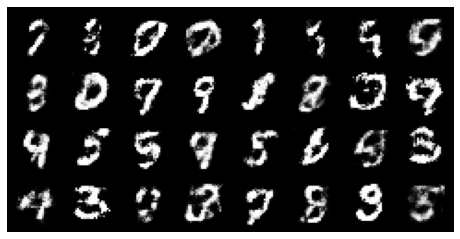

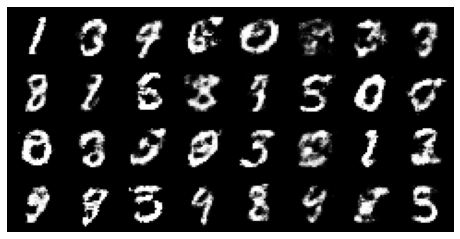

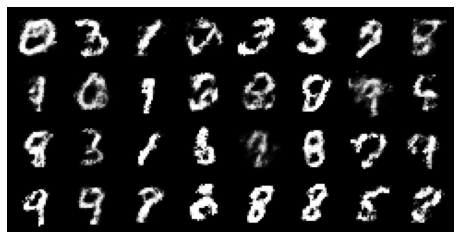

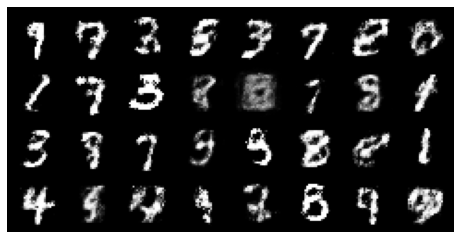

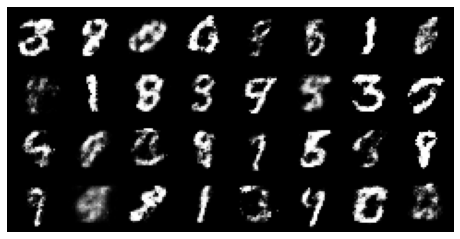

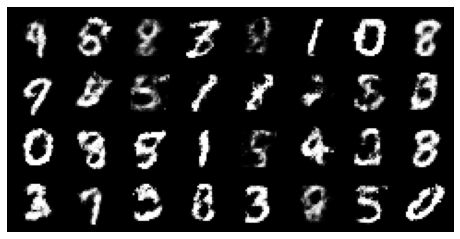

In [8]:
# Training Loop 
epochs = 20
for i in trange(epochs):
    for x, _ in trainloader:
        #==================
        # Discriminator 
        #==================
        x_real = x.to(device).view(-1, 28*28)
        n = len(x)
        x_fake = torch.randn(n, z_dim).to(device)
        y_real = torch.ones(n, 1).to(device)
        y_fake = torch.zeros(n, 1).to(device)

        # Training 
        fake_out = d(g(x_fake))
        fake_loss = loss_function(fake_out, y_fake)
        real_out = d(x_real)
        real_loss = loss_function(real_out, y_real)
        d_loss = fake_loss + real_loss

        # Update Weights 
        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        #==================
        # Generator 
        #==================

        x_fake = torch.randn(n, z_dim).to(device)
        y_real = torch.ones(n, 1).to(device)

        # Training 
        fake_images = g(x_fake)
        fake_out = d(fake_images)
        g_loss = loss_function(fake_out, y_real)

        # Update Weights 
        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

    # Print Data 
    if i == 1 or i % 4 == 0:
        print(f"g_losses = {g_loss.item():.3f}, d_losses = {d_loss.item():.3f}")
        fake_images = fake_images.view(fake_images.shape[0], 1, 28, 28)
        plot_g_images(fake_images)


